# Przewidywanie cen mieszkań na podstawie cech nieruchomości
Opis: Model uczenia maszynowego przewidujący cenę mieszkania na podstawie liczby
pokoi, metrażu, lokalizacji itp.

Użyty zbiór danych: **Ames Housing Dataset**

In [14]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

if(not os.path.isdir('data')):
    path = kagglehub.dataset_download("shashanknecrothapa/ames-housing-dataset", output_dir='./data')
    print("Path to dataset:", path)

df = pd.read_csv('./data/AmesHousing.csv')

print(df.shape)  # (2930, 82)
df.head()

(2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# Przygotowanie danych

* Obsługa braków w danych
* Transformacja logarytmiczna ceny (log1p)
* Zamiana Stringów
* Usuwanie outliersów
* Standaryzacja (StandardScaler)

In [15]:
RANDOM_STATE = 40  

def add_ames_features(data):
    X = data.copy()
    X['Total SF'] = X.get('Total Bsmt SF', 0) + X.get('1st Flr SF', 0) + X.get('2nd Flr SF', 0)
    X['Total Bath'] = (
        X.get('Full Bath', 0) + 0.5 * X.get('Half Bath', 0) +
        X.get('Bsmt Full Bath', 0) + 0.5 * X.get('Bsmt Half Bath', 0)
    )
    X['House Age'] = X.get('Yr Sold', 2010) - X.get('Year Built', 2010)
    X['Remodel Age'] = X.get('Yr Sold', 2010) - X.get('Year Remod/Add', 2010)
    X['Garage Age'] = X.get('Yr Sold', 2010) - X.get('Garage Yr Blt', X.get('Yr Sold', 2010))
    X['Has Pool'] = (X.get('Pool Area', 0) > 0).astype(int)
    X['Has Garage'] = (X.get('Garage Area', 0) > 0).astype(int)
    X['Has Basement'] = (X.get('Total Bsmt SF', 0) > 0).astype(int)
    X['Has Fireplace'] = (X.get('Fireplaces', 0) > 0).astype(int)
    for col in ['House Age', 'Remodel Age', 'Garage Age']:
        X[col] = X[col].clip(lower=0)
    return X


df.drop(columns=['Order', 'PID', 'Mo Sold', 'Condition 2', 'Roof Matl', 'Heating'], inplace=True)

# Fill categorical "absent" columns with 'None'
none_cols = [ 'Alley', 'Mas Vnr Type', 'Bsmt Qual', 'Bsmt Cond',
                'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2',
                'Fireplace Qu', 'Garage Type', 'Garage Finish',
                'Garage Qual', 'Garage Cond', 'Pool QC', 'Fence', 'Misc Feature'
]
df[none_cols] = df[none_cols].fillna('None')

# Fill numeric absent columns with 0
zero_cols = [ 'Lot Frontage', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2',
                'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath',
                'Garage Cars', 'Garage Area', 'Garage Yr Blt'
]
df[zero_cols] = df[zero_cols].fillna(0)

df['Electrical'] = df['Electrical'].fillna('SBrkr')

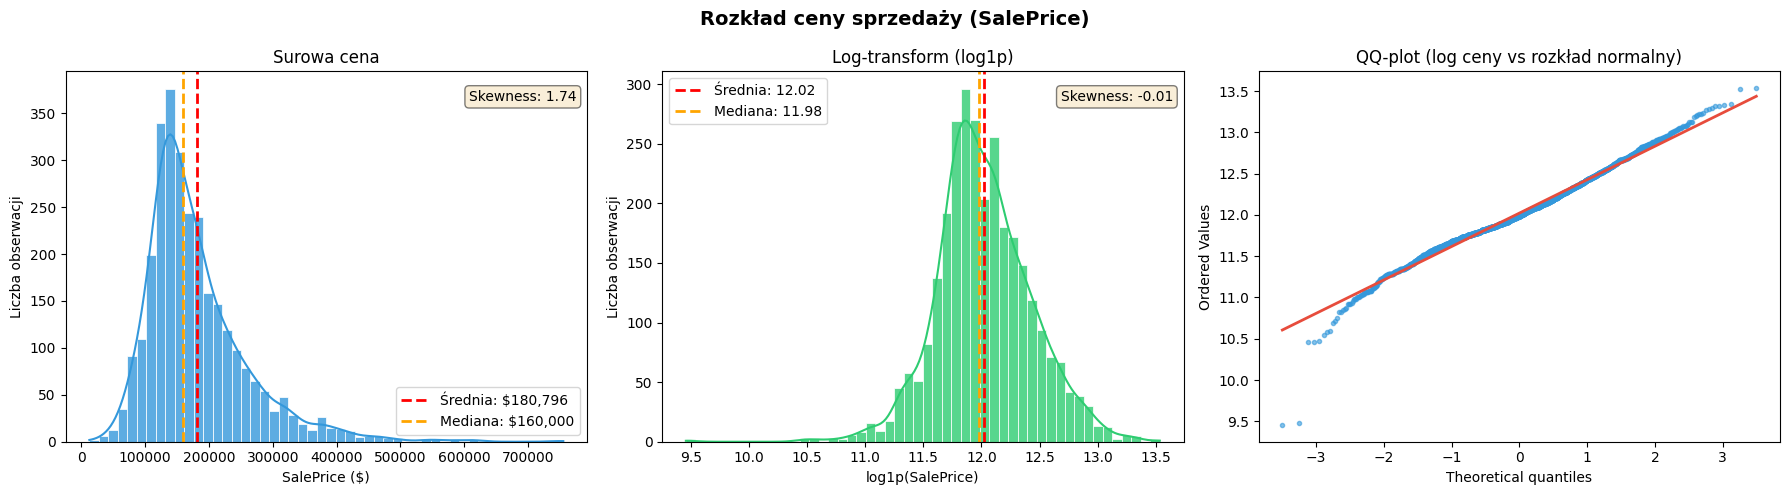

In [16]:
from scipy import stats
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Rozkład ceny sprzedaży (SalePrice)', fontsize=14, fontweight='bold')

y_all = df['SalePrice']

# Price distribution
ax = axes[0]
sns.histplot(y_all, bins=50, color='#3498db', alpha=0.8, edgecolor='white', kde=True, ax=ax)
ax.axvline(y_all.mean(), color='red', linestyle='--', linewidth=2, label=f'Średnia: ${y_all.mean():,.0f}')
ax.axvline(y_all.median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: ${y_all.median():,.0f}')
ax.set_title('Surowa cena')
ax.set_xlabel('SalePrice ($)')
ax.set_ylabel('Liczba obserwacji')
ax.legend()
skew_val = stats.skew(y_all)
ax.text(0.98, 0.95, f'Skewness: {skew_val:.2f}', transform=ax.transAxes,
        ha='right', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Log-transform
y_log = np.log1p(y_all)
ax = axes[1]
sns.histplot(y_log, bins=50, color='#2ecc71', alpha=0.8, edgecolor='white', kde=True, ax=ax)
ax.axvline(y_log.mean(), color='red', linestyle='--', linewidth=2, label=f'Średnia: {y_log.mean():.2f}')
ax.axvline(y_log.median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {y_log.median():.2f}')
ax.set_title('Log-transform (log1p)')
ax.set_xlabel('log1p(SalePrice)')
ax.set_ylabel('Liczba obserwacji')
ax.legend()
skew_log = stats.skew(y_log)
ax.text(0.98, 0.95, f'Skewness: {skew_log:.2f}', transform=ax.transAxes,
        ha='right', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# QQ-plot
ax = axes[2]
stats.probplot(y_log, dist='norm', plot=ax)
ax.set_title('QQ-plot (log ceny vs rozkład normalny)')
ax.get_lines()[0].set(color='#3498db', alpha=0.6, markersize=3)
ax.get_lines()[1].set(color='#e74c3c', linewidth=2)

plt.tight_layout()
plt.show()

In [17]:
outliers = df[y_log < 10.0]
df.drop(outliers.index, inplace=True)

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SalePrice'])
X = add_ames_features(X)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

In [19]:
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

In [20]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, TargetEncoder

ordinal_cols = {
    'Lot Shape':        ['IR3', 'IR2', 'IR1', 'Reg'],
    'Utilities':        ['ELO', 'NoSeWa', 'NoSewr', 'AllPub'],
    'Land Slope':       ['Gtl', 'Mod', 'Sev'],
    'Exter Qual':       ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Exter Cond':       ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Qual':        ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Cond':        ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Exposure':    ['None', 'No', 'Mn', 'Av', 'Gd'],
    'BsmtFin Type 1':   ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'BsmtFin Type 2':   ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'Central Air':      ['N', 'Y'],
    'Electrical':       ['Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr'],
    'Kitchen Qual':     ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Functional':       ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    'Fireplace Qu':     ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Garage Finish':    ['None', 'Unf', 'RFn', 'Fin'],
    'Garage Qual':      ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Garage Cond':      ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Paved Drive':      ['N', 'P', 'Y'],
    'Pool QC':          ['None', 'Fa', 'TA', 'Gd', 'Ex'],
    'Fence':            ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
    'Heating QC':       [ 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
}

for col, order in ordinal_cols.items():
    enc = OrdinalEncoder(
    categories=[order],
    handle_unknown='use_encoded_value',
    unknown_value=-1
    )
    X_train[col] = enc.fit_transform(X_train[[col]]).ravel()
    X_test[col] = enc.transform(X_test[[col]]).ravel()

one_hot_cols = [ 'MS Zoning', 'Street', 'Alley', 'Land Contour',
                    'Lot Config', 'Bldg Type', 'House Style', 'Roof Style',
                    'Mas Vnr Type', 'Foundation',
                ]

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=float)

ohe_train = pd.DataFrame(ohe.fit_transform(X_train[one_hot_cols]), columns=ohe.get_feature_names_out(one_hot_cols), index=X_train.index)
ohe_test = pd.DataFrame(ohe.transform(X_test[one_hot_cols]), columns=ohe.get_feature_names_out(one_hot_cols), index=X_test.index)

X_train = pd.concat([X_train.drop(columns=one_hot_cols), ohe_train], axis=1)
X_test = pd.concat([X_test.drop(columns=one_hot_cols), ohe_test], axis=1)

target_cols = [  'MS SubClass', 'Neighborhood', 'Condition 1', 'Garage Type',
                    'Misc Feature', 'Sale Type', 'Sale Condition', 'Exterior 1st',
                    'Exterior 2nd'
                ]

te = TargetEncoder(target_type="continuous", random_state=RANDOM_STATE)
X_train[target_cols] = te.fit_transform(X_train[target_cols], y_train)
X_test[target_cols]  = te.transform(X_test[target_cols])

c:\Users\Staszek\Documents\GitHub\flat-price\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [21]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

known_outlier_mask = (
    (X_train['Gr Liv Area'] > 4000) &
    (y_train < 300000)
)

price_per_sf = y_train / X_train['Total SF'].replace(0, np.nan)
q_low, q_high = price_per_sf.quantile([0.005, 0.995])
price_per_sf_flag = (price_per_sf < q_low) | (price_per_sf > q_high)

outlier_review = pd.DataFrame({
    'SalePrice': y_train,
    'Gr Liv Area': X_train['Gr Liv Area'],
    'Total SF': X_train['Total SF'],
    'Overall Qual': X_train.get('Overall Qual'),
    'price_per_sf': price_per_sf,
    'known_large_low_price': known_outlier_mask,
    'extreme_price_per_sf': price_per_sf_flag,
}).sort_values(['known_large_low_price', 'extreme_price_per_sf', 'SalePrice'], ascending=[False, False, True])

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso.fit(X_train)

train_iso_mask  = iso.predict(X_train) == -1
train_iso_scores = iso.score_samples(X_train)

print(f"IsolationForest train outliers: {train_iso_mask.sum()} ({train_iso_mask.mean()*100:.1f}%)")
print(f'Known train outliers removed automatically: {known_outlier_mask.sum()}')
display(outlier_review.head(5))


IsolationForest train outliers: 118 (5.0%)
Known train outliers removed automatically: 3


,SalePrice,Gr Liv Area,Total SF,Overall Qual,price_per_sf,known_large_low_price,extreme_price_per_sf
1498,160000,5642,11752.0,10,13.614704,True,True
2180,183850,5095,10190.0,10,18.042198,True,True
2181,184750,4676,7814.0,10,23.643460,True,True
726,34900,720,1440.0,4,24.236111,False,True
709,37900,968,1568.0,3,24.170918,False,True


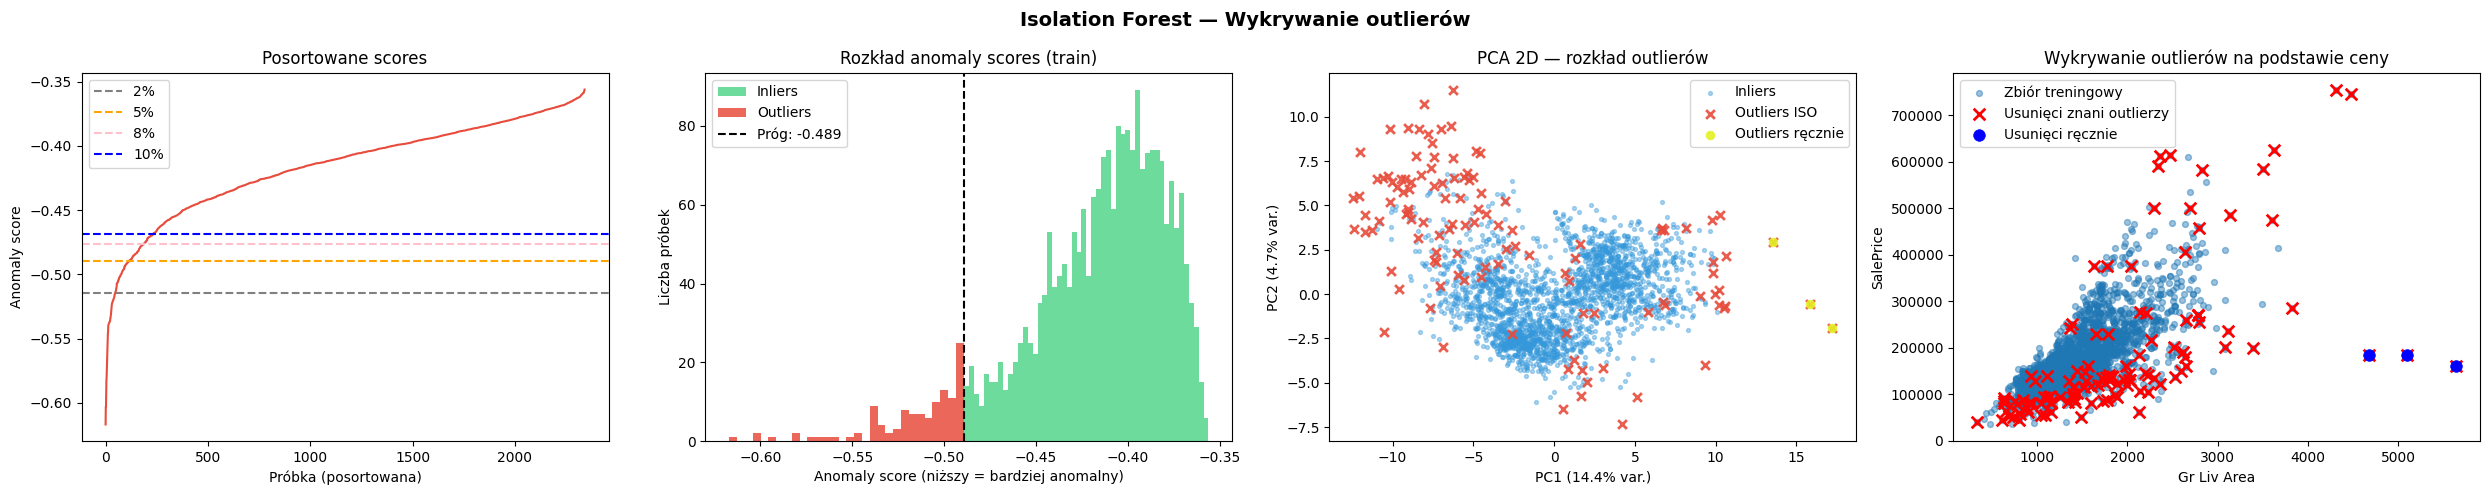

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(25, 5))
fig.suptitle("Isolation Forest — Wykrywanie outlierów", fontsize=14, fontweight='bold')

# Elbow method for contamination
scores = iso.score_samples(X_train)
ax = axes[0]
ax.plot(np.sort(scores), color='#e74c3c', linewidth=1.5)
ax.set_title('Posortowane scores')
ax.set_xlabel('Próbka (posortowana)')
ax.set_ylabel('Anomaly score')
ax.axhline(np.percentile(scores, 2), color='gray',
                linestyle='--', label='2%')
ax.axhline(np.percentile(scores, 5), color='orange',
                linestyle='--', label='5%')
ax.axhline(np.percentile(scores, 8), color='pink',
                linestyle='--', label='8%')
ax.axhline(np.percentile(scores, 10), color='blue',
                linestyle='--', label='10%')
ax.legend()

# Histogram anomaly scores
ax = axes[1]
ax.hist(train_iso_scores[~train_iso_mask], bins=50,
        color='#2ecc71', alpha=0.7, label='Inliers')
ax.hist(train_iso_scores[train_iso_mask], bins=30,
        color='#e74c3c', alpha=0.85, label='Outliers')
ax.axvline(iso.offset_, color='black', linestyle='--',
           linewidth=1.5, label=f'Próg: {iso.offset_:.3f}')
ax.set_title('Rozkład anomaly scores (train)')
ax.set_xlabel('Anomaly score (niższy = bardziej anomalny)')
ax.set_ylabel('Liczba próbek')
ax.legend()

# PCA 2D scatter
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(StandardScaler().fit_transform(X_train))

ax = axes[2]
ax.scatter(X_2d[~train_iso_mask, 0], X_2d[~train_iso_mask, 1],
           s=8, alpha=0.4, color='#3498db', label='Inliers')
ax.scatter(X_2d[train_iso_mask, 0], X_2d[train_iso_mask, 1],
           s=40, alpha=0.9, color='#e74c3c', marker='x',
           linewidths=2, label='Outliers ISO')
ax.scatter(X_2d[known_outlier_mask, 0], X_2d[known_outlier_mask, 1],
           s=40, alpha=0.9, color="#e4f124d1", marker='o',
           linewidths=0.5, label='Outliers ręcznie')
ax.set_title('PCA 2D — rozkład outlierów')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)')
ax.legend()

ax = axes[3]
ax.scatter(X_train['Gr Liv Area'], y_train, s=18, alpha=0.45, label='Zbiór treningowy')
ax.scatter(
    X_train.loc[train_iso_mask, 'Gr Liv Area'],
    y_train.loc[train_iso_mask],
    s=70, marker='x', color='red', linewidths=2, label='Usunięci znani outlierzy'
)
ax.scatter(
    X_train.loc[known_outlier_mask, 'Gr Liv Area'],
    y_train.loc[known_outlier_mask],
    s=70, marker='o', color='blue', linewidths=0.5, label='Usunięci ręcznie'
)
ax.set_xlabel('Gr Liv Area')
ax.set_ylabel('SalePrice')
ax.set_title('Wykrywanie outlierów na podstawie ceny')
ax.legend()

plt.tight_layout()
plt.show()

X_train_clean = X_train[~train_iso_mask & ~known_outlier_mask]
y_train_clean = y_train[~train_iso_mask & ~known_outlier_mask]
y_train_log = y_train_log[~train_iso_mask & ~known_outlier_mask]
X_test_clean = X_test
y_test_clean = y_test

## Skalowanie

In [23]:
scaler = StandardScaler()
X_train_clean_scaled = scaler.fit_transform(X_train_clean)
X_test_clean_scaled  = scaler.transform(X_test_clean)

print(f"X_train_clean: {X_train_clean_scaled.shape}")
print(f"X_test_clean:  {X_test_clean_scaled.shape}")
print(f"y_train_clean: {y_train_clean.shape}")
print(f"y_test_clean:  {y_test_clean.shape}")

X_train_clean: (2224, 124)
X_test_clean:  (586, 124)
y_train_clean: (2224,)
y_test_clean:  (586,)


# Wizualizacja danych

* Macierz korelacji (top 20)
* Wykresy cecha × cena 
* Wizualizacje 2D - PCA / t-SNE / UMAP

## 1. Macierz korelacji (Top 20 cech)

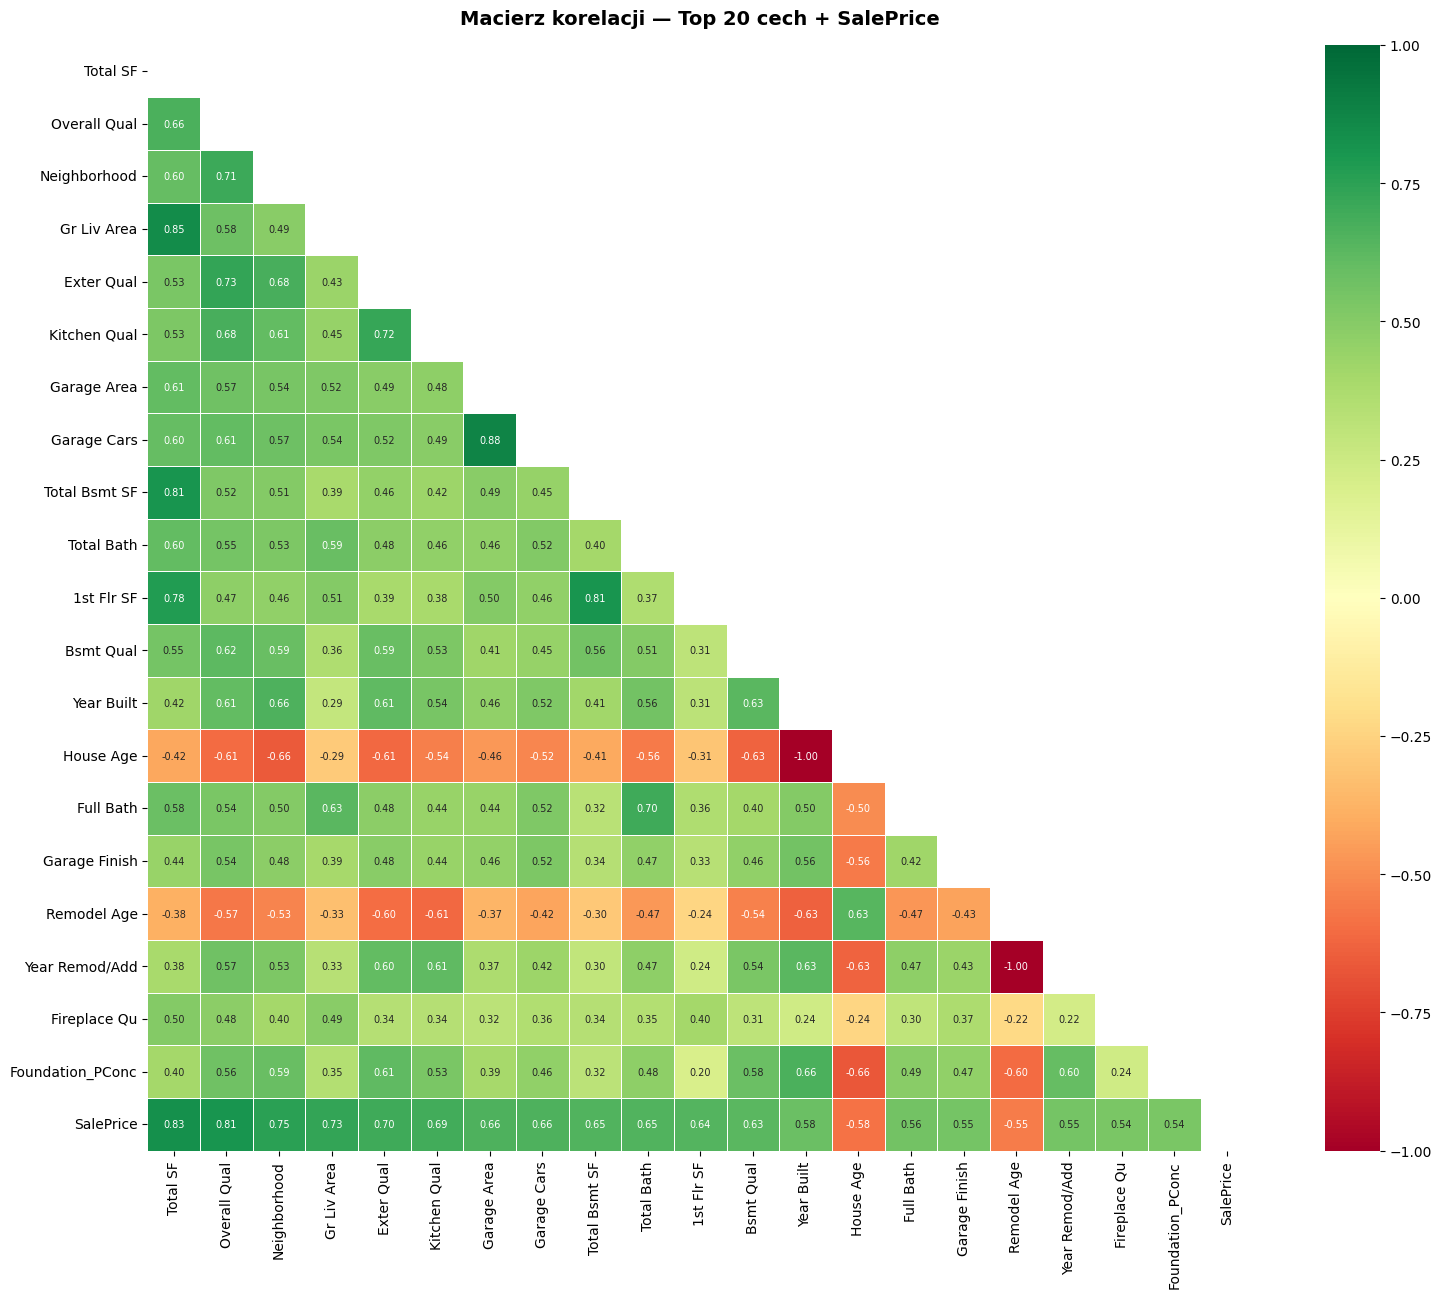

In [24]:
import seaborn as sns

df_analysis = X_train_clean.copy()
df_analysis['SalePrice'] = y_train_clean.values

# Korelacja Pearsona z ceną
corr_with_price = df_analysis.corr()['SalePrice'].drop('SalePrice')
top20 = corr_with_price.abs().nlargest(20).index.tolist()
top20_sorted = corr_with_price.abs().nlargest(20).index.tolist()
cols_for_corr = top20_sorted + ['SalePrice']
corr_matrix = df_analysis[cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # tylko dolny trójkąt

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 7}
)

ax.set_title('Macierz korelacji — Top 20 cech + SalePrice', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 2. Wykresy cecha × cena

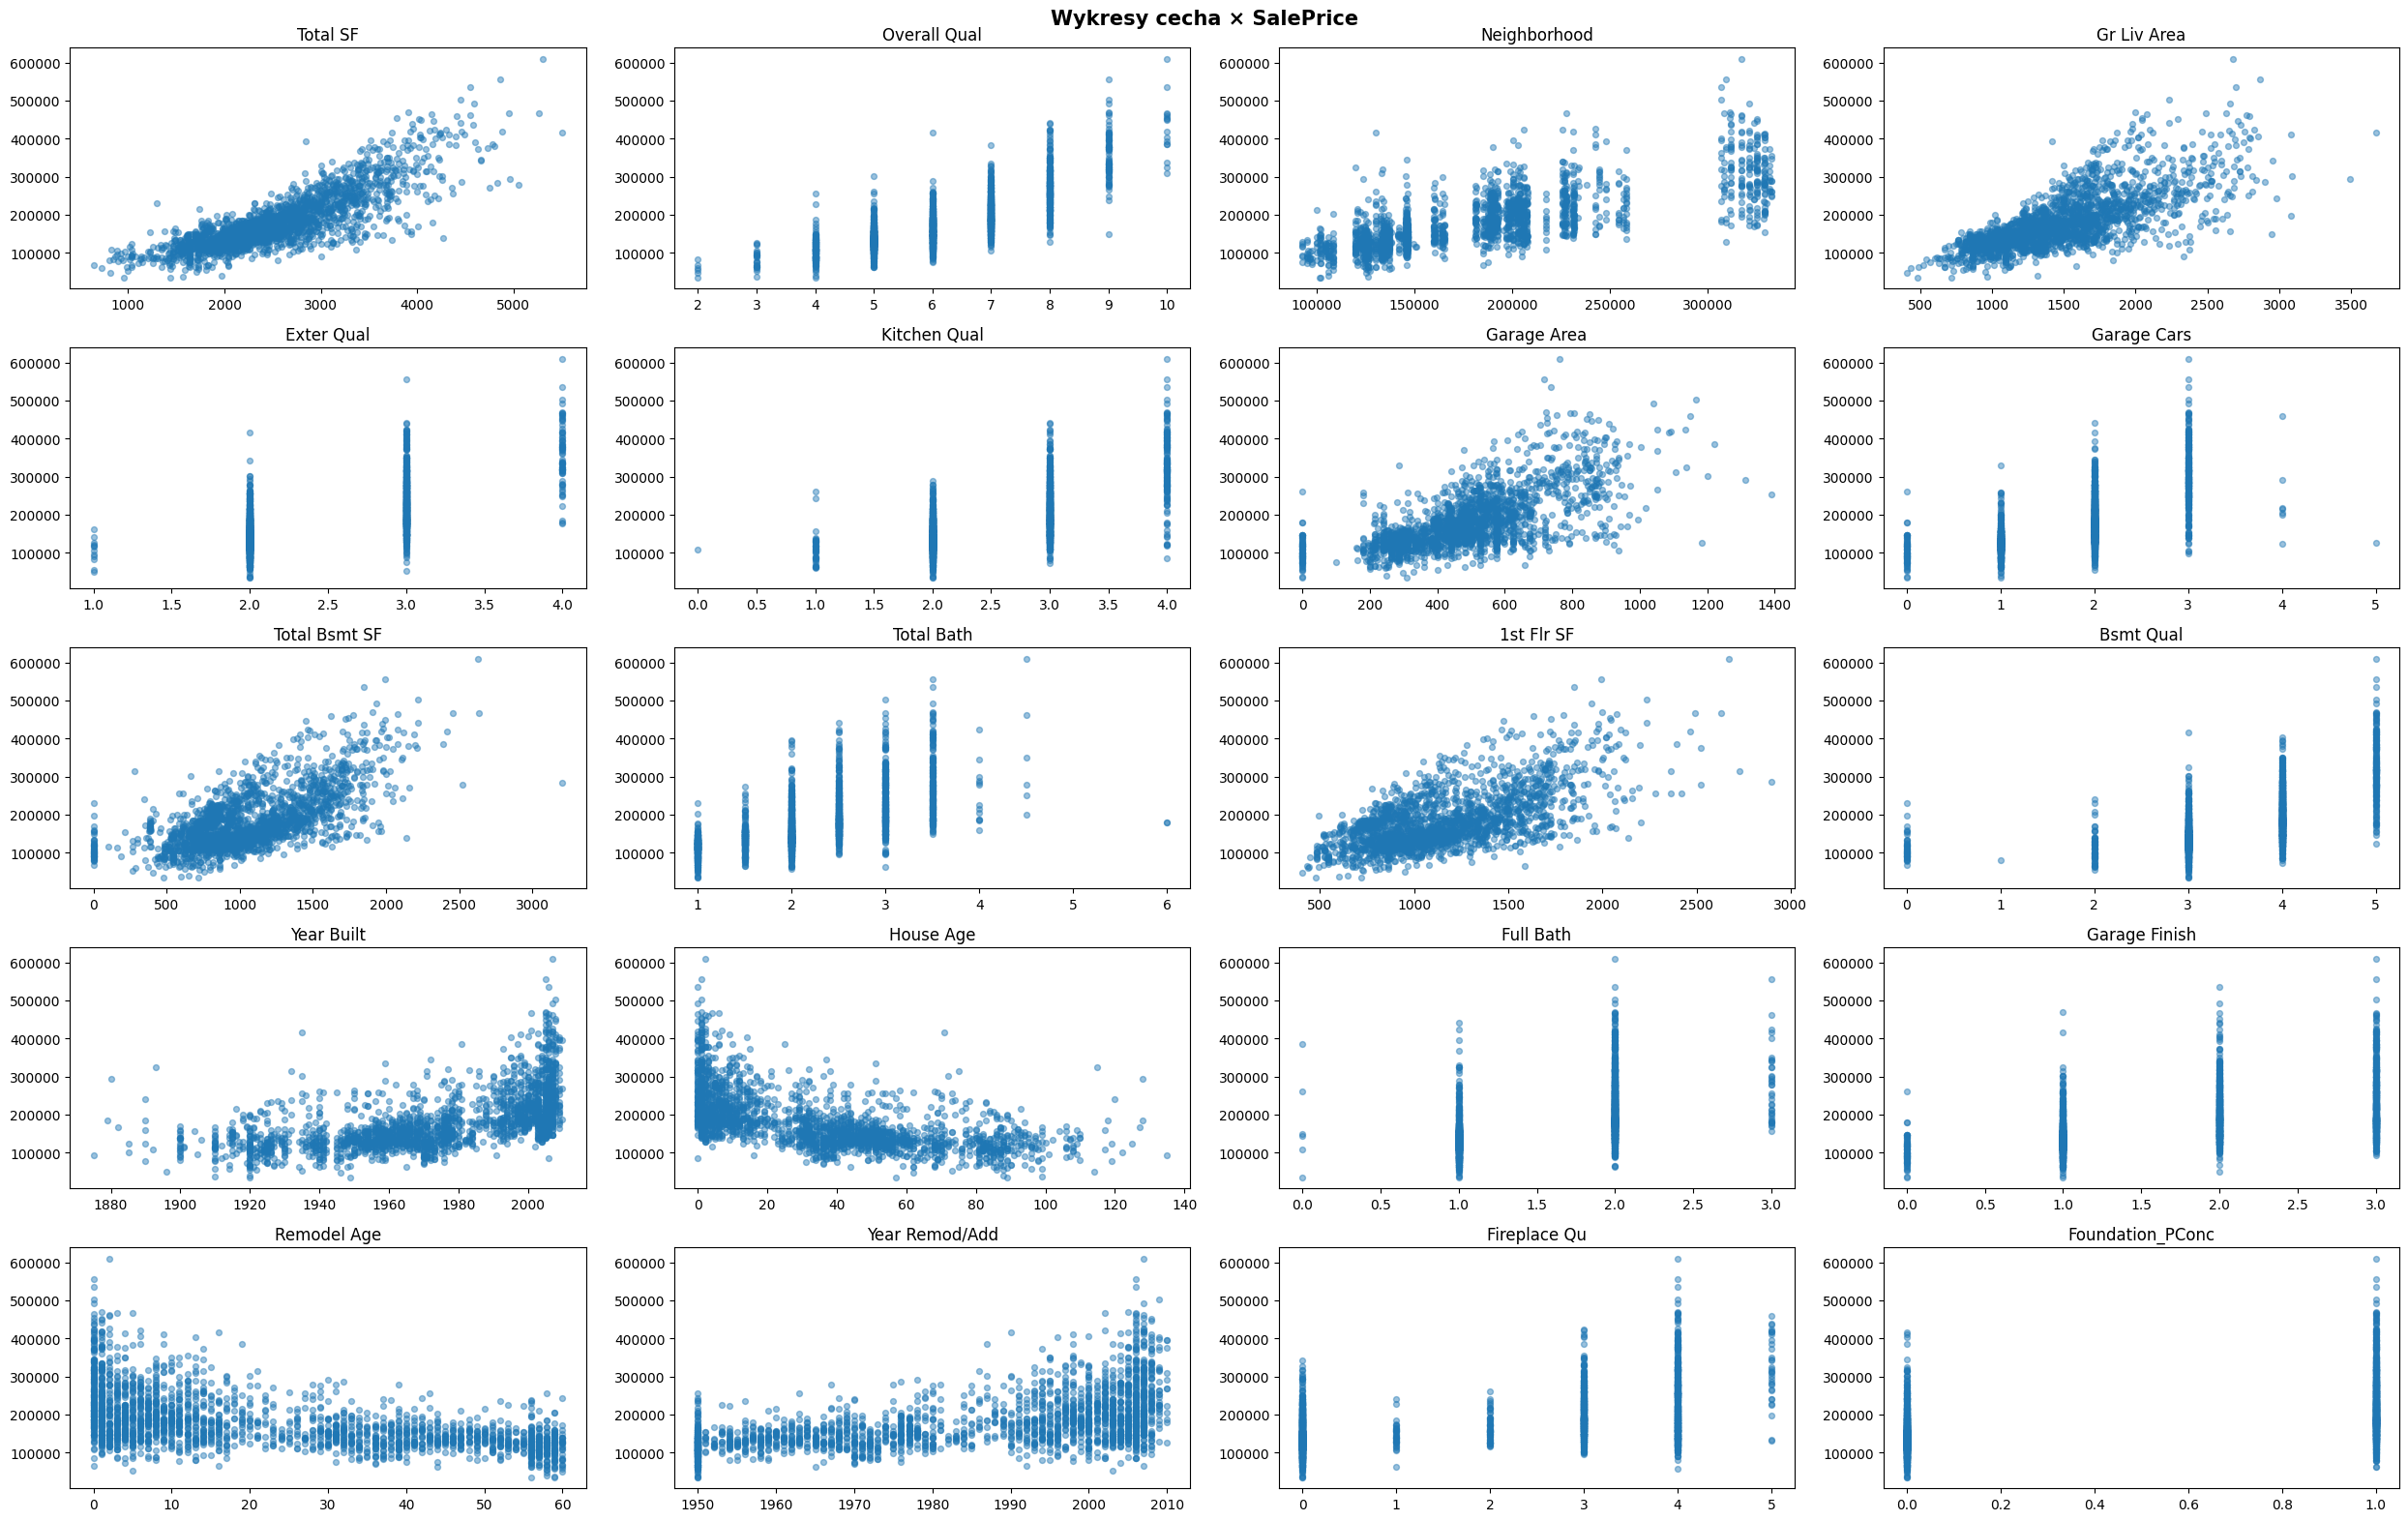

In [25]:
fig, axes = plt.subplots(5, 4, figsize=(25, 16))
fig.suptitle('Wykresy cecha × SalePrice', fontsize=15, fontweight='bold')

for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        feature = top20_sorted[i*4+j]
        ax.scatter(X_train_clean[feature], y_train_clean, s=18, alpha=0.45)
        # ax.set_xlabel(feature)
        # ax.set_ylabel('SalePrice')
        ax.set_title(feature)

plt.tight_layout()
plt.show()

## 3. Redukcja wymiarów do 2D: PCA / t-SNE / UMAP (kolorowane ceną)

c:\Users\Staszek\Documents\GitHub\flat-price\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


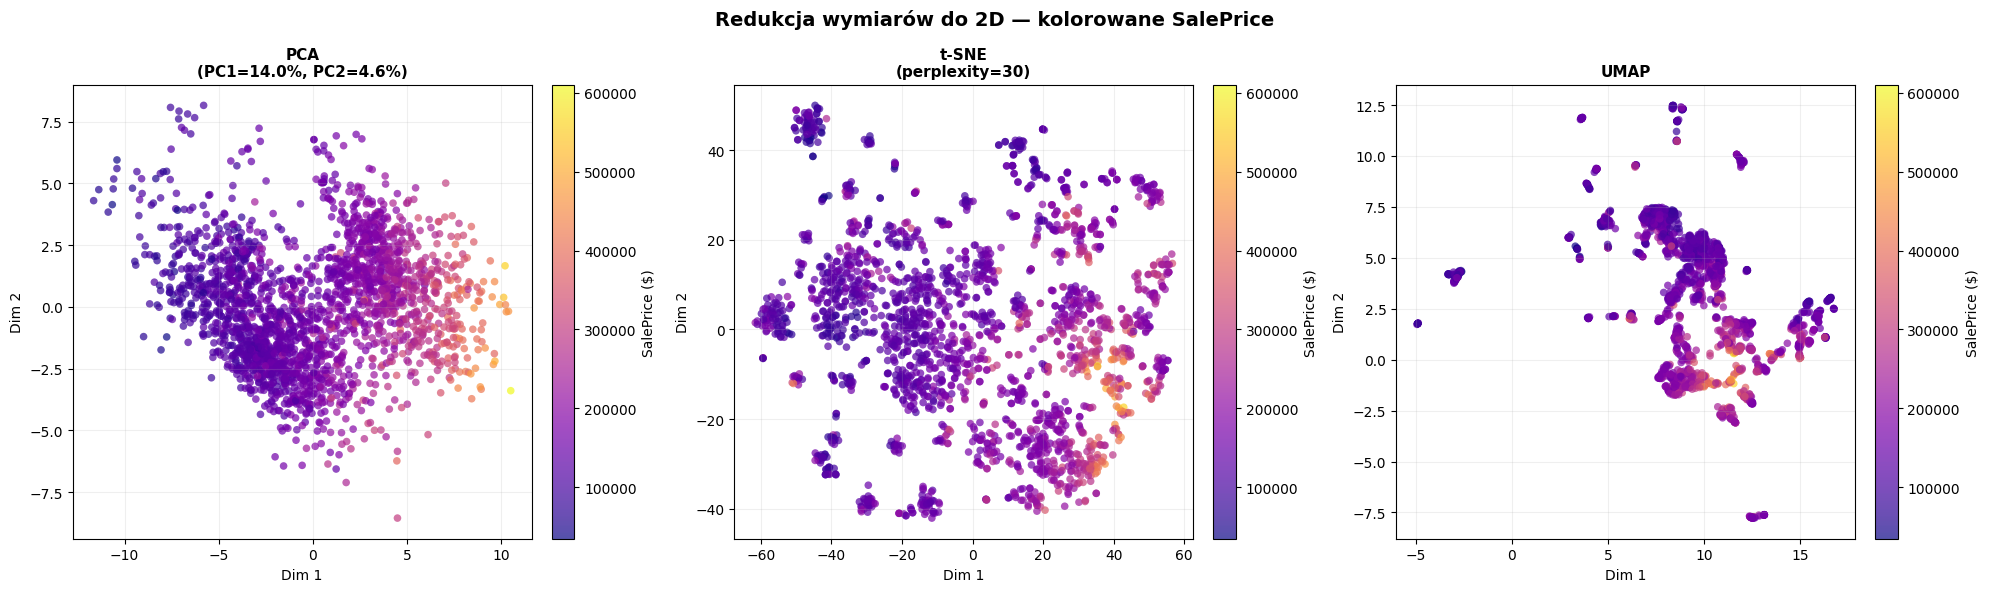

In [26]:
from sklearn.manifold import TSNE
import umap

np.random.seed(42)
n_sample = min(2500, X_train_clean_scaled.shape[0])
idx_sample = np.random.choice(X_train_clean_scaled.shape[0], n_sample, replace=False)
X_sample = X_train_clean_scaled[idx_sample]
y_sample = y_train_clean.values[idx_sample]

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca2.fit_transform(X_sample)

tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, max_iter=1000, verbose=0)
X_tsne = tsne.fit_transform(X_sample)

reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE, verbose=False)
X_umap = reducer.fit_transform(X_sample)
umap_available = True

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Redukcja wymiarów do 2D — kolorowane SalePrice', fontsize=14, fontweight='bold')

datasets = [
    (X_pca,  f'PCA\n(PC1={pca2.explained_variance_ratio_[0]*100:.1f}%, PC2={pca2.explained_variance_ratio_[1]*100:.1f}%)'),
    (X_tsne, 't-SNE\n(perplexity=30)'),
    (X_umap, 'UMAP' if umap_available else 'Kernel PCA (rbf)\n[UMAP nie zainstalowany]'),
]

for ax, (X_2d, title) in zip(axes, datasets):
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_sample,
                    cmap='plasma', s=30, alpha=0.7, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='SalePrice ($)', fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Modele

## 1. Regresja liniowa


                    RMSE_$       MAE_$        R²    RMSLE
Linear Regresion      19761      13734   0.9115   0.1194


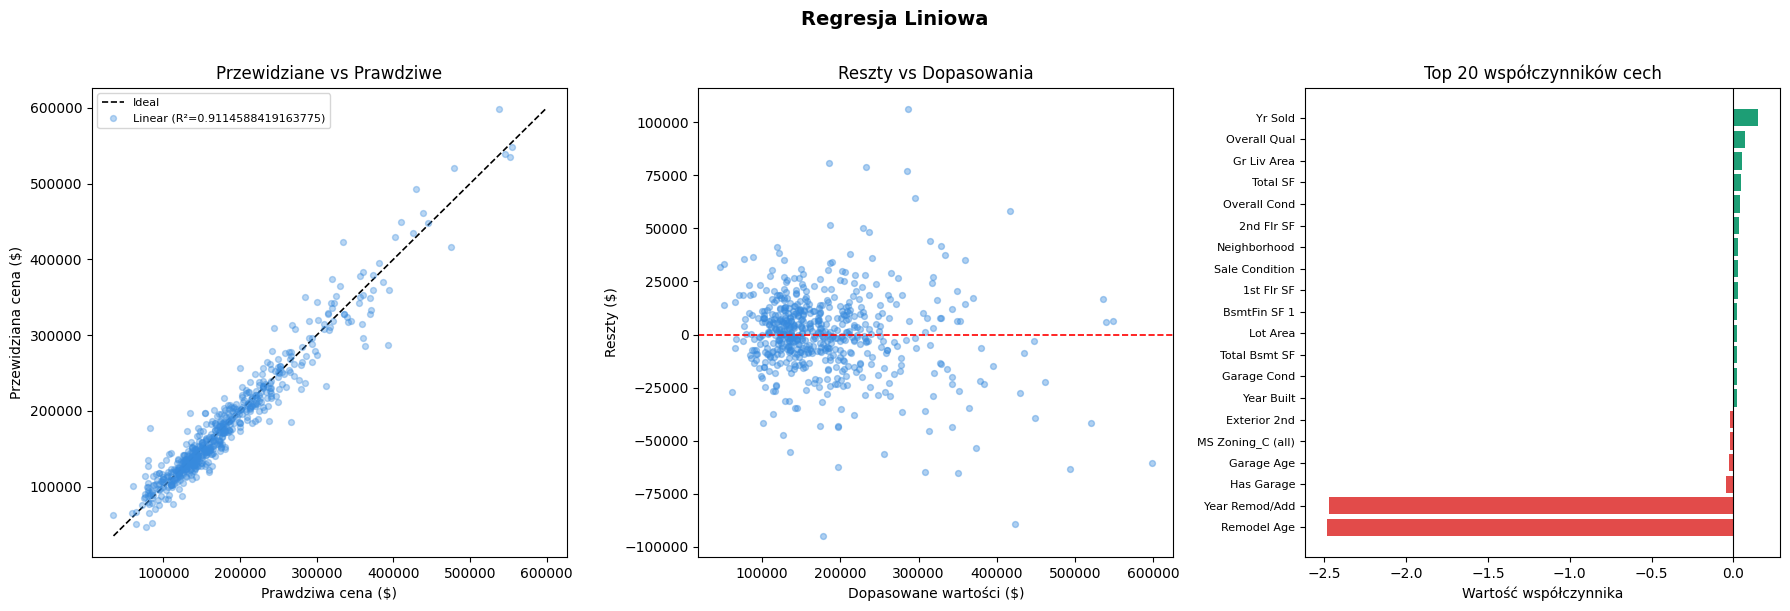

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

reg = LinearRegression()
reg.fit(X_train_clean_scaled, y_train_log)
reg_y_pred_log = reg.predict(X_test_clean_scaled)
reg_y_pred = np.expm1(reg_y_pred_log)

# Metrics
n_test = len(y_test_clean)
n_features = X_test_clean_scaled.shape[1]

mse   = mean_squared_error(y_test_clean, reg_y_pred)
rmse  = np.sqrt(mse)
mae   = mean_absolute_error(y_test_clean, reg_y_pred)
r2    = r2_score(y_test_log, reg_y_pred_log)
rmsle = np.sqrt(mean_squared_error(np.log1p(y_test_clean), np.log1p(reg_y_pred)))
print(f"\n                {'RMSE_$':>10}  {'MAE_$':>10}  {'R²':>8} {'RMSLE':>8}")
print(f"Linear Regresion {rmse:>10.0f} {mae:>10.0f} {r2:>8.4f} {rmsle:>8.4f}")

# Plots
fig = plt.figure(figsize=(18, 6))

# ── Wykres 1: Predicted vs Actual
ax1 = fig.add_subplot(131)
y_min = min(y_test_clean.min(), reg_y_pred.min())
y_max = max(y_test_clean.max(), reg_y_pred.max())
ax1.plot([y_min, y_max], [y_min, y_max], 'k--', lw=1.2, label='Ideal', zorder=1)
ax1.scatter(y_test_clean, reg_y_pred, alpha=0.35, s=18, color='#378ADD', label=f"Linear (R²={r2})", zorder=2)
ax1.set_xlabel('Prawdziwa cena ($)')
ax1.set_ylabel('Przewidziana cena ($)')
ax1.set_title('Przewidziane vs Prawdziwe')
ax1.legend(fontsize=8)

# ── Wykres 2: Residuals vs Fitted
ax2 = fig.add_subplot(132)
residuals = y_test_clean - reg_y_pred
ax2.axhline(0, color='red', lw=1.2, ls='--')
ax2.scatter(reg_y_pred, residuals, alpha=0.4, s=18, color='#378ADD')
ax2.set_xlabel('Dopasowane wartości ($)')
ax2.set_ylabel('Reszty ($)')
ax2.set_title(f'Reszty vs Dopasowania')

# ── Wykres 3: Top-20 feature importance
ax3 = fig.add_subplot(133)
coefs = pd.Series(reg.coef_, index=df_analysis.columns[:-1])
top20 = coefs.abs().nlargest(20).index
coefs_top = coefs[top20].sort_values()
bar_colors = ['#1D9E75' if v > 0 else '#E24B4A' for v in coefs_top]
ax3.barh(coefs_top.index, coefs_top.values, color=bar_colors)
ax3.axvline(0, color='black', lw=0.8)
ax3.set_title('Top 20 współczynników cech')
ax3.set_xlabel('Wartość współczynnika')
ax3.tick_params(axis='y', labelsize=8)

plt.suptitle('Regresja Liniowa', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2. Drzewo decyzyjne

In [28]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

parameters = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.05] 
}

clf = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid=parameters,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)
clf.fit(X_train_clean_scaled, y_train_log)
print(f"Tree best params: {clf.best_params_}")

dt = clf.best_estimator_
dt_y_pred_log = dt.predict(X_test_clean_scaled)
dt_y_pred = np.expm1(dt_y_pred_log)

mse   = mean_squared_error(y_test_clean, dt_y_pred)
rmse  = np.sqrt(mse)
mae   = mean_absolute_error(y_test_clean, dt_y_pred)
r2    = r2_score(y_test_log, dt_y_pred_log)
rmsle = np.sqrt(mean_squared_error(np.log1p(y_test_clean), np.log1p(dt_y_pred)))
print(f"\n                {'RMSE_$':>10}  {'MAE_$':>10}  {'R²':>8} {'RMSLE':>8}")
print(f"Decision Tree {rmse:>10.0f} {mae:>10.0f} {r2:>8.4f} {rmsle:>8.4f}")

Tree best params: {'ccp_alpha': 0.0, 'max_depth': 15, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}

                    RMSE_$       MAE_$        R²    RMSLE
Decision Tree      29506      20374   0.8327   0.1642


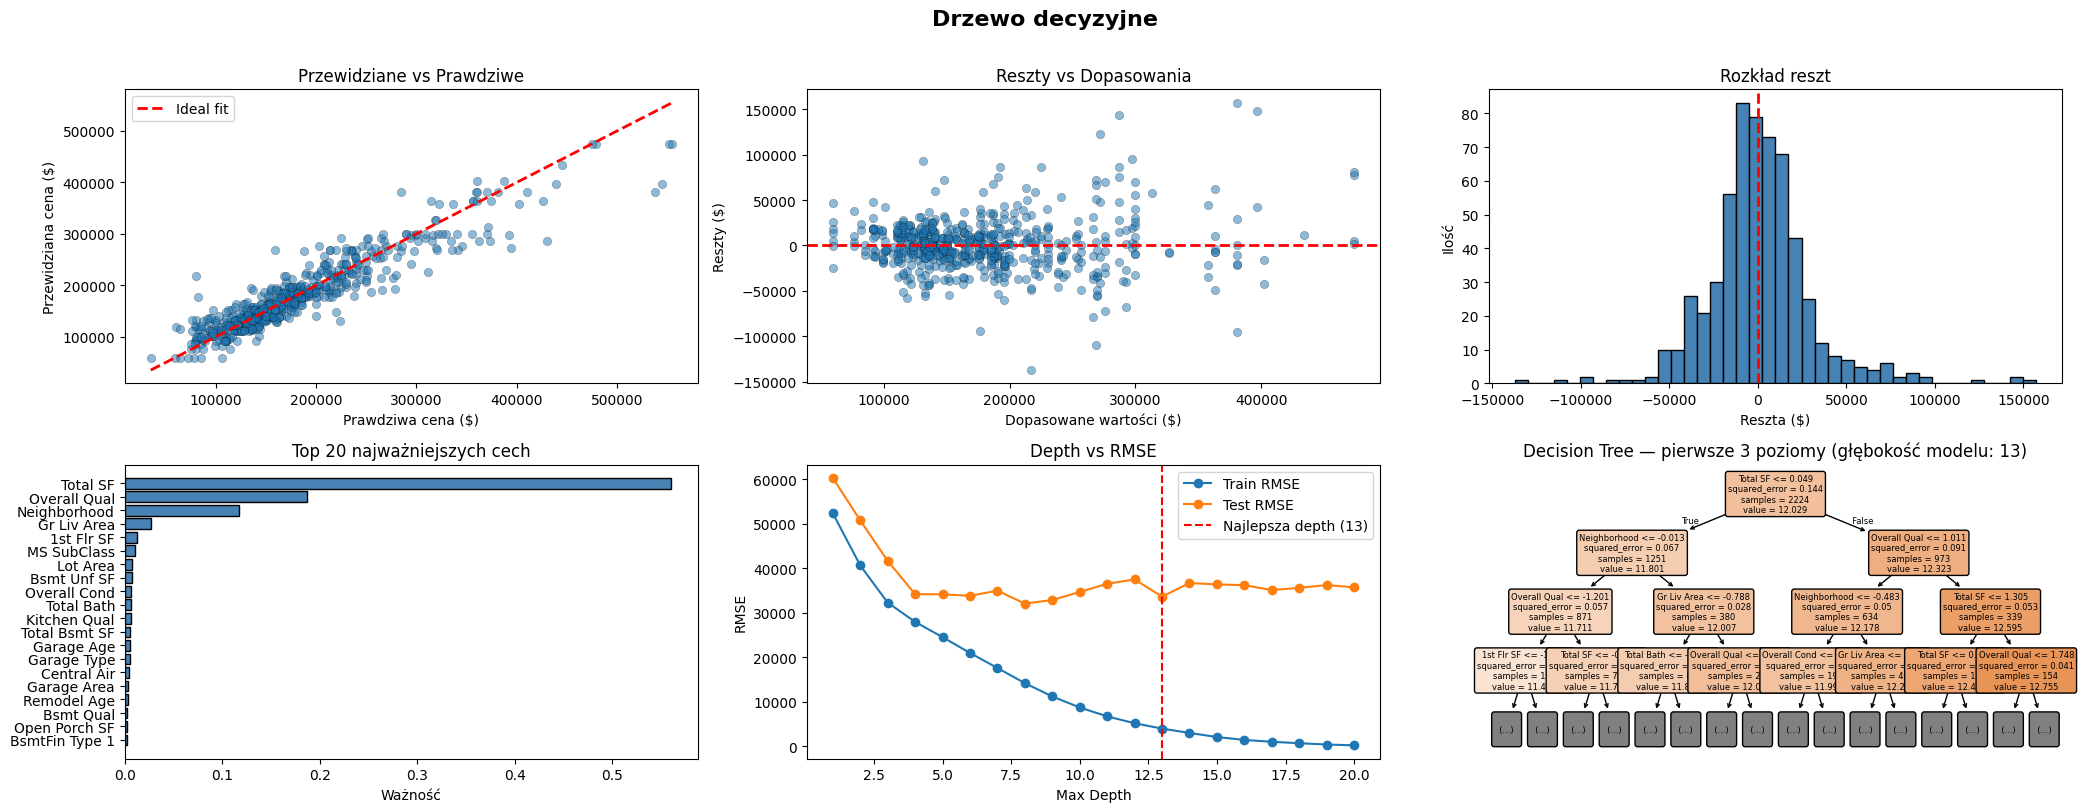

In [29]:
from sklearn.tree import plot_tree

residuals = y_test_clean - dt_y_pred

fig = plt.figure(figsize=(21, 8))

# ── 1. Predicted vs Actual ──────────────────────────────────────────────────
ax1 = fig.add_subplot(231)
ax1.scatter(y_test_clean, dt_y_pred, alpha=0.5, edgecolors='k', linewidths=0.3)
min_val = min(y_test_clean.min(), dt_y_pred.min())
max_val = max(y_test_clean.max(), dt_y_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal fit')
ax1.set_xlabel('Prawdziwa cena ($)')
ax1.set_ylabel('Przewidziana cena ($)')
ax1.set_title("Przewidziane vs Prawdziwe")
ax1.legend()

# ── 2. Residual Plot ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(232)
ax2.scatter(dt_y_pred, residuals, alpha=0.5, edgecolors='k', linewidths=0.3)
ax2.axhline(0, color='red', linestyle='--', lw=2)
ax2.set_xlabel('Dopasowane wartości ($)')
ax2.set_ylabel('Reszty ($)')
ax2.set_title(f'Reszty vs Dopasowania')

# ── 3. Residual Distribution ────────────────────────────────────────────────
ax3 = fig.add_subplot(233)
ax3.hist(residuals, bins=40, edgecolor='black', color='steelblue')
ax3.axvline(0, color='red', linestyle='--', lw=2)
ax3.set_xlabel("Reszta ($)")
ax3.set_ylabel("Ilość")
ax3.set_title("Rozkład reszt")

# ── 4. Feature Importance (Top 20) ─────────────────────────────────────────
ax4 = fig.add_subplot(234)
importances = dt.feature_importances_
feature_names = df_analysis.columns.to_list()
indices = np.argsort(importances)[::-1][:20]
ax4.barh(
    [feature_names[i] for i in indices[::-1]],
    importances[indices[::-1]],
    color='steelblue', edgecolor='black'
)
ax4.set_xlabel("Ważność")
ax4.set_title("Top 20 najważniejszych cech")

# ── 5. Depth vs RMSE ────────────────────────────────────────────────────────
ax5 = fig.add_subplot(235)
depths = range(1, 21)
train_rmses, test_rmses = [], []
for d in depths:
    tmp = DecisionTreeRegressor(max_depth=d, random_state=42)
    tmp.fit(X_train_clean_scaled, y_train_clean)
    train_rmses.append(np.sqrt(mean_squared_error(y_train_clean, tmp.predict(X_train_clean_scaled))))
    test_rmses.append(np.sqrt(mean_squared_error(y_test_clean,  tmp.predict(X_test_clean_scaled))))

ax5.plot(depths, train_rmses, 'o-', label='Train RMSE')
ax5.plot(depths, test_rmses,  'o-', label='Test RMSE')
ax5.axvline(dt.get_depth(), color='red', linestyle='--', label=f'Najlepsza depth ({dt.get_depth()})')
ax5.set_xlabel("Max Depth")
ax5.set_ylabel("RMSE")
ax5.set_title("Depth vs RMSE")
ax5.legend()

# ── 6. Tree Visualization ───────────────────────────────────────────────────
ax6 = fig.add_subplot(236)
plot_tree(
    dt,
    max_depth=3,
    feature_names=df_analysis.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=6,
    ax=ax6
)
ax6.set_title(f"Decision Tree — pierwsze 3 poziomy (głębokość modelu: {dt.get_depth()})")

plt.suptitle("Drzewo decyzyjne", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Regresja wielomianowa 
   - wybor 20 best cech (RFE lub SelectKBest)
   - opytmalizacja parametrów - degree
   - regularyzacja
   - metryki (MSE, R², Adjusted R²)
   - wykresy działania (Predicted vs Actual, Residuals vs Fitted, Degree vs MSE (train/val))

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression, VarianceThreshold  
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning

simplefilter("ignore", category=ConvergenceWarning)
simplefilter("ignore", category=RuntimeWarning)

poly = PolynomialFeatures(degree=2, include_bias=False)
selector = SelectKBest(score_func=f_regression, k=25)

pipe_linear = Pipeline([
    ('selector', selector),
    ('poly', poly),
    ('variance_threshold', VarianceThreshold(threshold=1e-5)),
    ('model', LinearRegression())
])
pipe_linear.fit(X_train_clean_scaled, y_train_log)
reg_linear_y_pred_log = pipe_linear.predict(X_test_clean_scaled)
reg_linear_y_pred = np.expm1(reg_linear_y_pred_log)

pipe_ridge = Pipeline([
    ('selector', selector),
    ('poly', poly),
    ('variance_threshold', VarianceThreshold(threshold=1e-5)),
    ('model', Ridge())
])
ridge_params = {'model__alpha': [0.01, 0.1, 1.0, 3.0]}
ridge_gs = GridSearchCV(pipe_ridge, ridge_params, cv=5, scoring='neg_mean_squared_error')
ridge_gs.fit(X_train_clean_scaled, y_train_log)
reg_ridge_y_pred_log = ridge_gs.predict(X_test_clean_scaled)
reg_ridge_y_pred = np.expm1(reg_ridge_y_pred_log)
print(f"Ridge best alpha: {ridge_gs.best_params_['model__alpha']}")

pipe_lasso = Pipeline([
    ('selector', selector),
    ('poly', poly),
    ('variance_threshold', VarianceThreshold(threshold=1e-5)),
    ('model', Lasso(max_iter=10000))
])
lasso_params = {'model__alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 3.0]}
lasso_gs = GridSearchCV(pipe_lasso, lasso_params, cv=5, scoring='neg_mean_squared_error')
lasso_gs.fit(X_train_clean_scaled, y_train_log)
reg_lasso_y_pred_log = lasso_gs.predict(X_test_clean_scaled)
reg_lasso_y_pred = np.expm1(reg_lasso_y_pred_log)
print(f"Lasso best alpha: {lasso_gs.best_params_['model__alpha']}")


n_test = len(y_test_clean)
n_features = 40

models = {
    'Linear':  (reg_linear_y_pred_log, reg_linear_y_pred, pipe_linear),
    'Ridge':   (reg_ridge_y_pred_log, reg_ridge_y_pred, ridge_gs.best_estimator_),
    'Lasso':   (reg_lasso_y_pred_log, reg_lasso_y_pred, lasso_gs.best_estimator_),
}

print(f"\n{'Model':<10} {'RMSE':>10} {'MAE':>10} {'R²':>8} {'RMSLE':>10}")
print("─" * 52)
results = {}
for name, (y_pred_log, y_pred, model) in models.items():
    mse  = mean_squared_error(y_test_clean, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_clean, y_pred)
    r2   = r2_score(y_test_log, y_pred_log)
    rmsle = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
    results[name] = dict(y_pred=y_pred, rmse=rmse, mae=mae, r2=r2, rmsle=rmsle, model=model)
    print(f"{name:<10} {rmse:>10.0f} {mae:>10.0f} {r2:>8.4f} {rmsle:>8.4f}")

Ridge best alpha: 3.0
Lasso best alpha: 0.001

Model            RMSE        MAE       R²      RMSLE
────────────────────────────────────────────────────
Linear          25581      17235   0.8711   0.1441
Ridge           24591      16721   0.8821   0.1378
Lasso           22024      15536   0.8949   0.1301


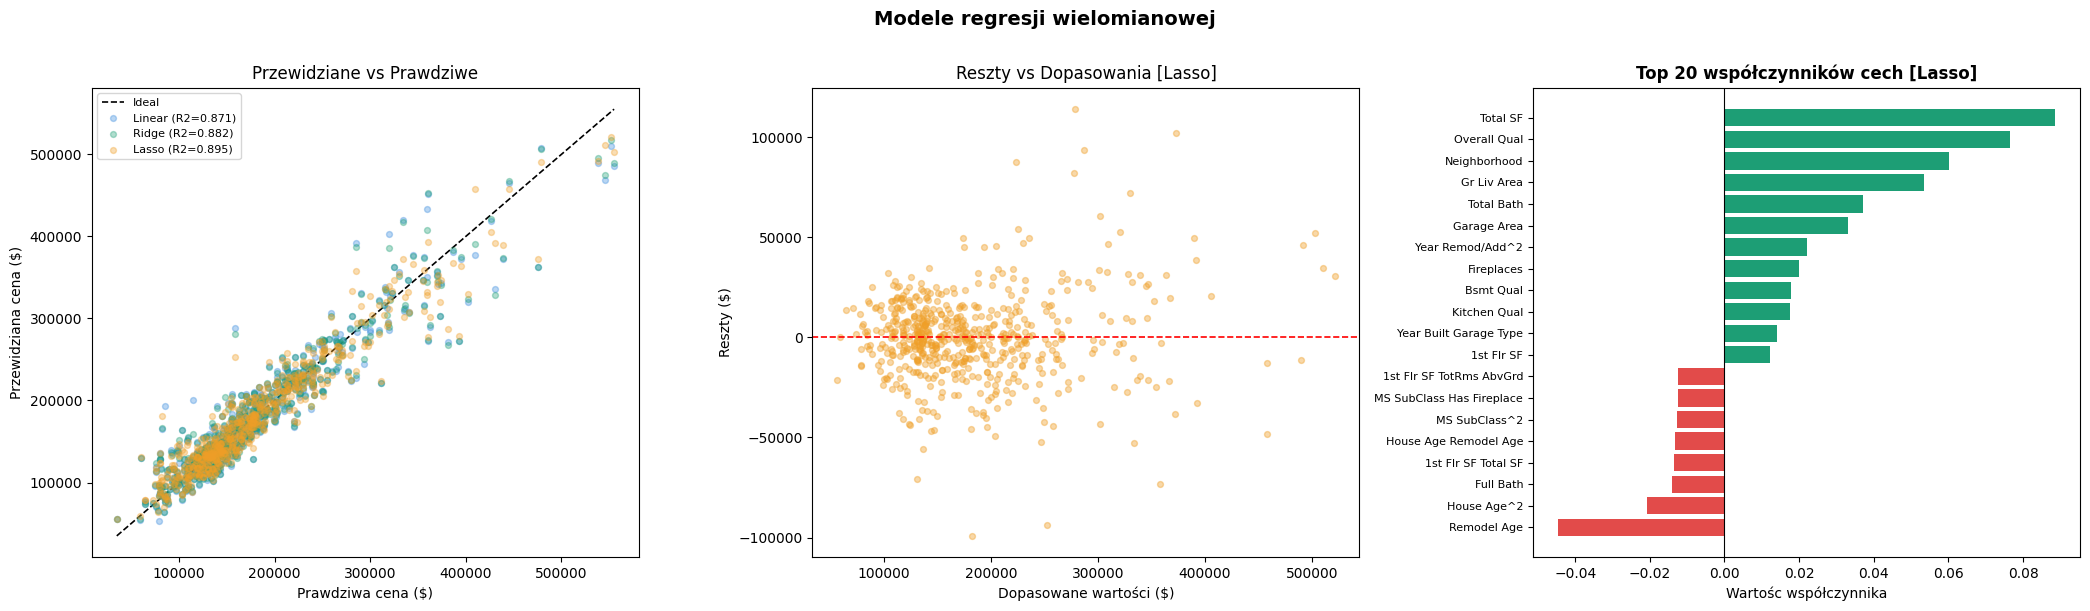

In [31]:
fig = plt.figure(figsize=(21, 6))
colors = {'Linear': '#378ADD', 'Ridge': '#1D9E75', 'Lasso': '#EF9F27'}

# -- Plot 1: Predicted vs Actual --
ax1 = fig.add_subplot(131)
y_min = min(y_test_clean.min(), min(r['y_pred'].min() for r in results.values()))
y_max = max(y_test_clean.max(), max(r['y_pred'].max() for r in results.values()))
ax1.plot([y_min, y_max], [y_min, y_max], 'k--', lw=1.2, label='Ideal', zorder=1)
for name, r in results.items():
    ax1.scatter(y_test_clean, r['y_pred'], alpha=0.35, s=18,
                color=colors[name], label=f"{name} (R2={r['r2']:.3f})", zorder=2)
ax1.set_xlabel('Prawdziwa cena ($)')
ax1.set_ylabel('Przewidziana cena ($)')
ax1.set_title("Przewidziane vs Prawdziwe")
ax1.legend(fontsize=8)

# -- Plot 2: Residuals vs Fitted --
ax2 = fig.add_subplot(132)
best_name = min(results, key=lambda n: results[n]['rmse'])
best = results[best_name]
residuals = y_test_clean - best['y_pred']
ax2.axhline(0, color='red', lw=1.2, ls='--')
ax2.scatter(best['y_pred'], residuals, alpha=0.4, s=18, color=colors[best_name])
ax2.set_xlabel('Dopasowane wartości ($)')
ax2.set_ylabel('Reszty ($)')
ax2.set_title(f'Reszty vs Dopasowania [{best_name}]')

# -- Plot 3: Top-20 polynomial coefficients --
ax3 = fig.add_subplot(133)
best_model = best['model']
selector_step = best_model.named_steps['selector']
poly_step = best_model.named_steps['poly']
vt_step = best_model.named_steps['variance_threshold']

# Feature names must pass through the same transformers as the data:
# SelectKBest -> PolynomialFeatures -> VarianceThreshold.
after_selector = selector_step.get_feature_names_out(X_train_clean.columns)
after_poly = poly_step.get_feature_names_out(after_selector)
selected_features = after_poly[vt_step.get_support()]

coefs = pd.Series(best_model.named_steps['model'].coef_, index=selected_features)
top20 = coefs.abs().nlargest(20).index
coefs_top = coefs[top20].sort_values()
bar_colors = ['#1D9E75' if v > 0 else '#E24B4A' for v in coefs_top]
ax3.barh(coefs_top.index, coefs_top.values, color=bar_colors)
ax3.axvline(0, color='black', lw=0.8)
ax3.set_title(f'Top 20 współczynników cech [{best_name}]', fontweight='bold')
ax3.set_xlabel('Wartośc współczynnika')
ax3.tick_params(axis='y', labelsize=8)

plt.suptitle('Modele regresji wielomianowej', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


# Final pipeline with better models


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import seaborn as sns

model_configs = {
    'Linear': {
        'model': LinearRegression(),
        'extra_steps': [],
    },
    'PolynomialRegression': {
        'model': Lasso(alpha=0.001,max_iter=10000),
        'extra_steps': [
            ('selector', SelectKBest(score_func=f_regression, k=40)),
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('variance_threshold', VarianceThreshold(threshold=1e-5)),
        ],
    },
    'DecisionTree': {
        'model': DecisionTreeRegressor(
            ccp_alpha=0.0, max_depth=10, max_features=None,
            min_samples_leaf=5, min_samples_split=20, random_state=RANDOM_STATE
        ),
        'extra_steps': [],
    },
    'RandomForest': {
        'model': RandomForestRegressor(
            n_estimators=100,
            max_features='sqrt',
            min_samples_leaf=2, 
            random_state=RANDOM_STATE, 
            n_jobs=None
        ),
        'extra_steps': [],
    },
    'HistGradientBoosting': {
        'model': HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.05,
            l2_regularization=0.03, 
            random_state=RANDOM_STATE
        ),
        'extra_steps': [],
    },
}

try:
    from xgboost import XGBRegressor
    model_configs['XGBoost'] = {
            'model': XGBRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=3,
                    min_child_weight=2,
                    subsample=0.85,
                    colsample_bytree=0.85,
                    reg_alpha=0.001,
                    reg_lambda=1.0,
                    objective='reg:squarederror',
                    random_state=RANDOM_STATE,
                    n_jobs=None,
                ),
            'extra_steps': [],
        }
except Exception as exc:
    print(f'XGBoost not available in this environment: {exc}')

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_metrics(y_true, y_true_log, pred_log):
    pred_log = np.maximum(pred_log, 0)
    pred = np.expm1(pred_log)

    return {
        "RMSE_$": np.sqrt(mean_squared_error(y_true, pred)),
        "MAE_$": mean_absolute_error(y_true, pred),
        "R2_log": r2_score(y_true_log, pred_log),
        "RMSLE": np.sqrt(mean_squared_error(y_true_log, pred_log))
    }

leaderboard = []
fitted_pipelines = {}

for name, config in model_configs.items():
    steps = config['extra_steps'] + [('model', config['model'])]
    pipe = Pipeline(steps)

    cv_rmse_log = -cross_val_score(
        pipe, X_train_clean_scaled, y_train_log,
        cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1
    ).mean()

    cv_r2 = cross_val_score(
        pipe, X_train_clean_scaled, y_train_log,
        cv=cv, scoring='r2', n_jobs=-1
    ).mean()

    pipe.fit(X_train_clean_scaled, y_train_log)
    pred = pipe.predict(X_test_clean_scaled)

    metrics = evaluate_metrics(y_test_clean, y_test_log, pred)
    metrics.update({'Model': name, 'CV_RMSE_log': cv_rmse_log, 'CV_R2': cv_r2})
    leaderboard.append(metrics)
    fitted_pipelines[name] = pipe

In [33]:
leaderboard = pd.DataFrame(leaderboard).sort_values(['CV_R2'], ascending=[False])
display(leaderboard)

best_model_name = leaderboard.iloc[0]['Model']
best_pipe = fitted_pipelines[best_model_name]
best_pred = np.expm1(best_pipe.predict(X_test_clean_scaled))
print(f'Best holdout model: {best_model_name}')

,RMSE_$,MAE_$,R2_log,RMSLE,Model,CV_RMSE_log,CV_R2
5,20677.557303,13414.004883,0.920480,0.113193,XGBoost,0.108581,0.917974
4,21640.066890,13738.252266,0.918687,0.114462,HistGradientBoosting,0.109945,0.915922
1,21332.292065,14522.464116,0.902666,0.125232,PolynomialRegression,0.118246,0.902790
3,26590.675373,16026.487618,0.889384,0.133503,RandomForest,0.122650,0.895688
0,19761.249888,13733.596619,0.911459,0.119442,Linear,0.133974,0.857443
2,29289.717310,19941.202033,0.828136,0.166409,DecisionTree,0.161240,0.818772


Best holdout model: XGBoost


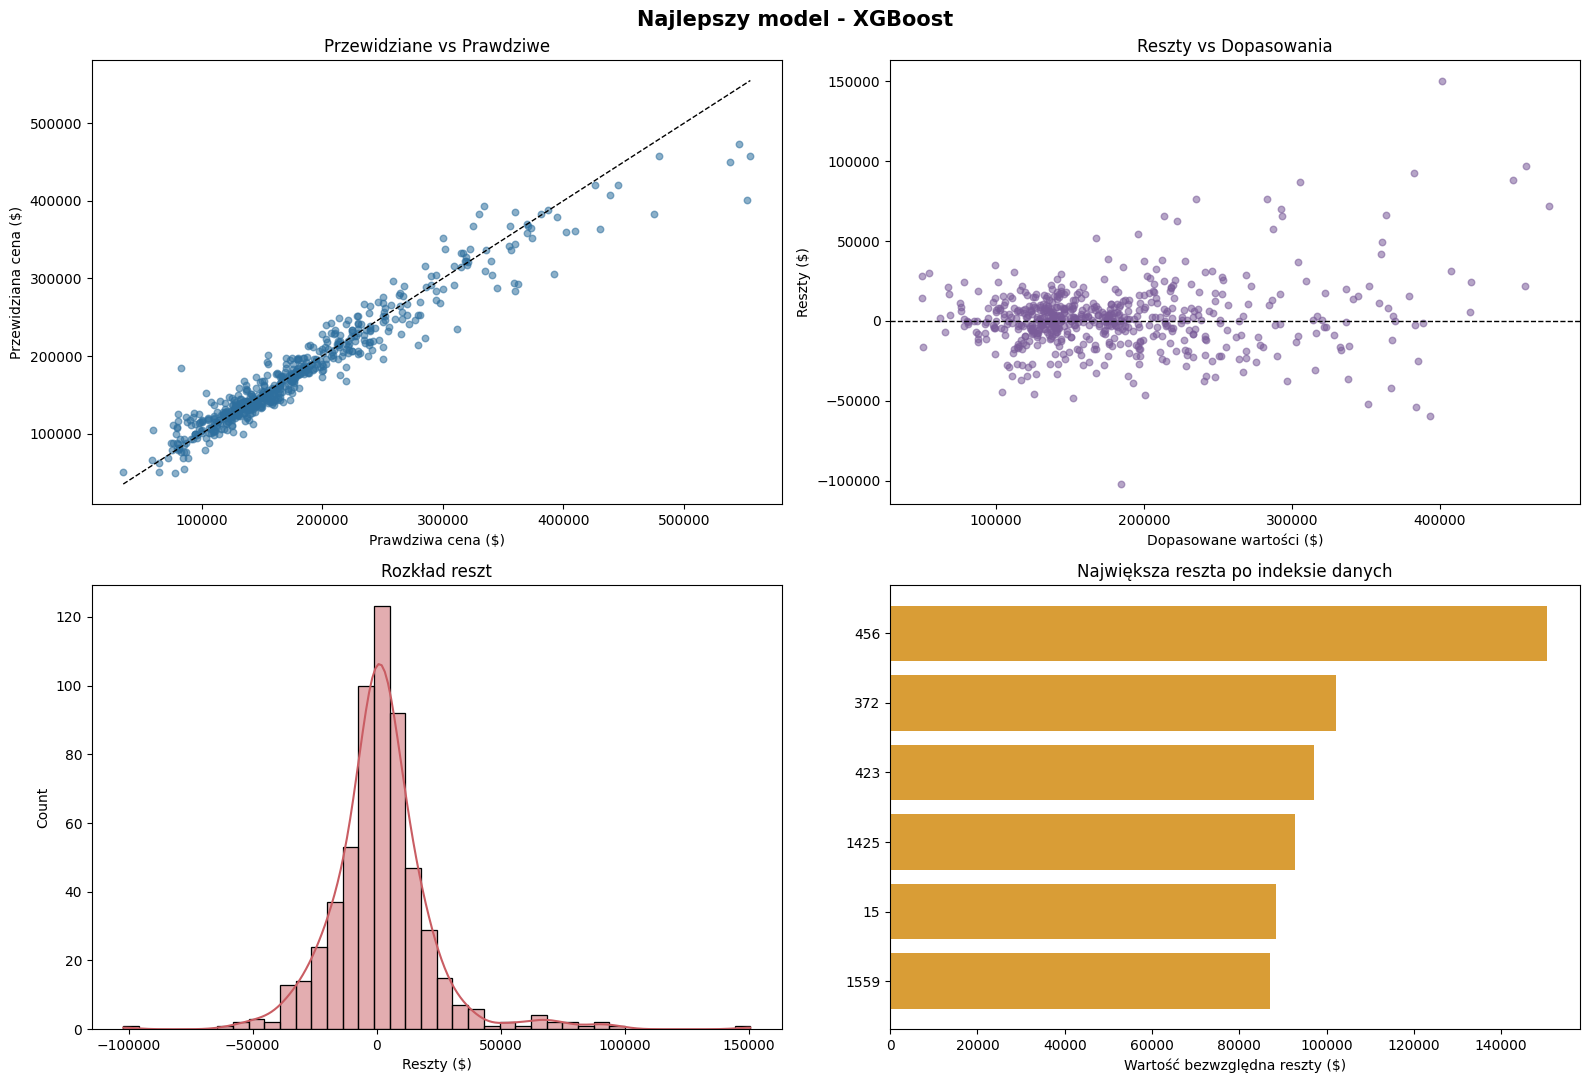

,Actual,Predicted,Residual,AbsResidual,Overall Qual,Gr Liv Area,Total SF
456,552000,401472.156250,150527.843750,150527.843750,10,2492,4984.0
372,82500,184633.578125,-102133.578125,102133.578125,7,1411,2797.0
423,555000,457873.062500,97126.937500,97126.937500,10,2402,5496.0
1425,475000,382361.375000,92638.625000,92638.625000,9,2276,4547.0
15,538000,449516.562500,88483.437500,88483.437500,8,3279,4929.0
1559,392500,305478.125000,87021.875000,87021.875000,8,1652,3252.0


In [34]:
residuals = y_test_clean - best_pred
abs_resid = residuals.abs()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(f'Najlepszy model - {best_model_name}', fontsize=15, fontweight='bold')

lo = min(y_test_clean.min(), best_pred.min())
hi = max(y_test_clean.max(), best_pred.max())
axes[0, 0].plot([lo, hi], [lo, hi], color='black', ls='--', lw=1)
axes[0, 0].scatter(y_test_clean, best_pred, s=22, alpha=0.55, color='#2E6F9E')
axes[0, 0].set_xlabel('Prawdziwa cena ($)')
axes[0, 0].set_ylabel('Przewidziana cena ($)')
axes[0, 0].set_title('Przewidziane vs Prawdziwe')

axes[0, 1].axhline(0, color='black', ls='--', lw=1)
axes[0, 1].scatter(best_pred, residuals, s=22, alpha=0.55, color='#7A5C99')
axes[0, 1].set_xlabel('Dopasowane wartości ($)')
axes[0, 1].set_ylabel('Reszty ($)')
axes[0, 1].set_title('Reszty vs Dopasowania')

sns.histplot(residuals, bins=40, kde=True, ax=axes[1, 0], color='#C95D63')
axes[1, 0].set_title('Rozkład reszt')
axes[1, 0].set_xlabel('Reszty ($)')

worst = pd.DataFrame({
    'Actual': y_test_clean,
    'Predicted': best_pred,
    'Residual': residuals,
    'AbsResidual': abs_resid,
    'Overall Qual': X_test_clean['Overall Qual'],
    'Gr Liv Area': X_test_clean['Gr Liv Area'],
    'Total SF': X_test_clean['Total SF'],
}).sort_values('AbsResidual', ascending=False).head(6)

axes[1, 1].barh(range(len(worst)), worst['AbsResidual'][::-1], color='#D99D36')
axes[1, 1].set_yticks(range(len(worst)))
axes[1, 1].set_yticklabels(worst.index[::-1])
axes[1, 1].set_xlabel('Wartość bezwzględna reszty ($)')
axes[1, 1].set_title('Największa reszta po indeksie danych')

plt.tight_layout()
plt.show()

display(worst)
